In [ ]:
%load_ext autoreload
%autoreload 2

# 量子传感仿真平台测试
本笔记演示利用仿真平台进行各种量子传感协议

## test1: Rabi振荡


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,  
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

# 总仿真时长
t_list = np.linspace(0, 50, 1000)  # ns

# 创建Protocal对象，设置测量协议和参数
protocal = Protocal(
    type = 0,
    params = {
        't_list': t_list,
    }
)

# 运行测量协议
protocal.initialize(qubit,state = 0)

print(f"qubit state before evolution: {qubit.state}")

results = protocal.evolve(qubit)

# 分析结果
analysis = Analysis()

p_e = analysis.get_expectation_values(results, e_ops_index = 0)

# 绘制结果
plt.figure(figsize=(8, 5))
plt.plot(t_list, p_e, label='Excited State Probability')
plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Rabi Oscillations')
plt.legend()
plt.grid()
plt.show()



## test2: Ramsey 干涉
- 需要完善：无法模拟非恒定信号的情况，如包络是高斯函数时
- 由于响应函数为余弦函数的绝对值，因此还原磁场时首先要考虑余弦函数的周期性和对称性，可能会有多个解，需要结合实际参数值以及估计的磁场范围判断正负值。

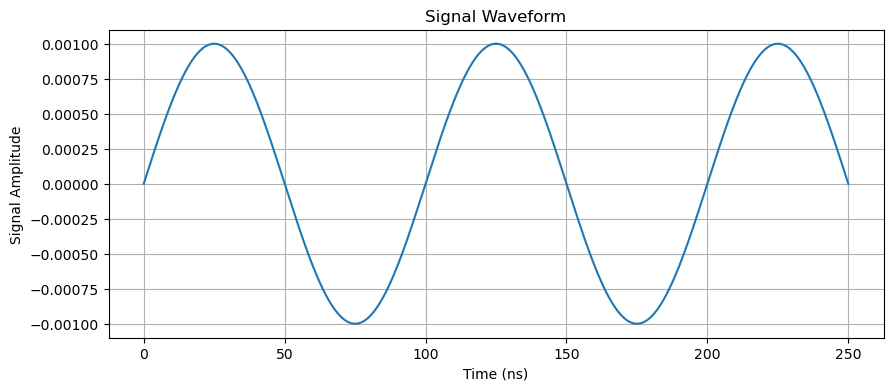

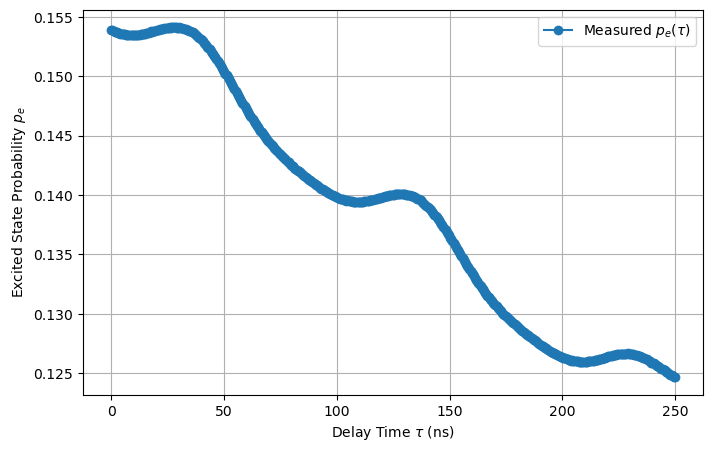

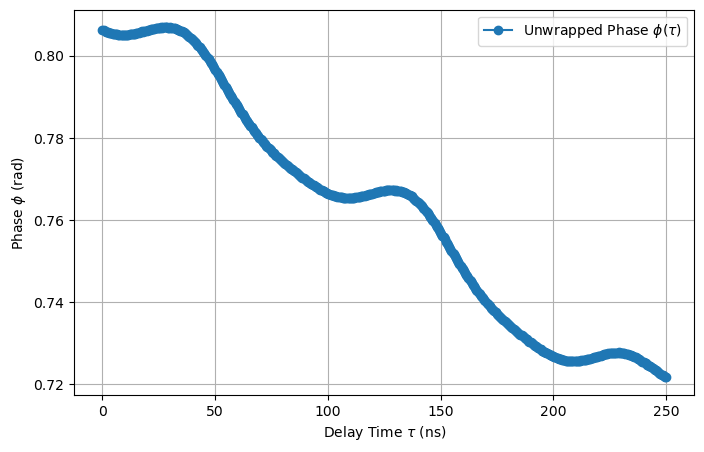

Index for time 40 ns: 80, Corresponding time: 40.08 ns


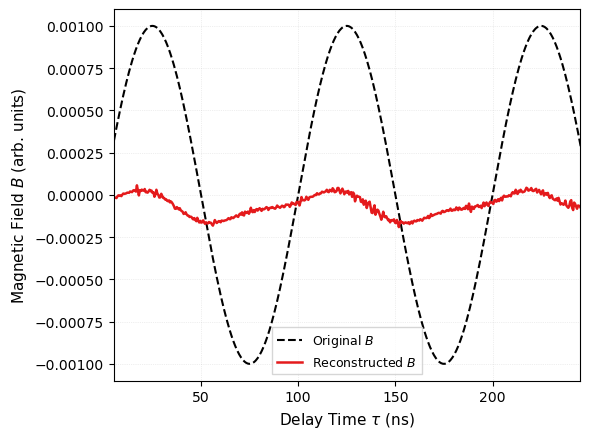

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)
Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
# 总仿真时长

protocal = Protocal(1)

protocal.initialize(qubit,state = 0)

Phi, tau_list, p_e_list = protocal.evolve(qubit)

analysis = Analysis()
B = analysis.get_signal_from_ramsey_by_unwrap(qubit, tau_list, p_e_list)

# varphi = np.unwrap(np.arccos(2 * np.array(p_e_list) - 1))  # 将概率转换为相位
# plt.figure(figsize=(8, 5))
# plt.plot(tau_list, varphi, label='Extracted Phase $\\varphi$')
# plt.xlabel('Delay Time $\\tau$ (ns)')
# plt.ylabel('Extracted Phase $\\varphi$ (radians)')
# plt.title('Extracted Phase from Ramsey Fringes')
# plt.legend()
# plt.grid()
# plt.show()
# B = np.zeros_like(varphi)  # 初始化磁场数组
# for i in range(1, len(tau_list)):
#     if 1 < i < len(tau_list) - 1:
#         B[i] = (varphi[i + 1] - varphi[i-1]) / (2 * (tau_list[i + 1] - tau_list[i]))  # 数值微分计算磁场
#     elif i <= 1:
#         B[i] = (varphi[i + 1] - varphi[i]) / (tau_list[i + 1] - tau_list[i])  # 前向差分
#     else:
#         B[i] = (varphi[i] - varphi[i - 1]) / (tau_list[i] - tau_list[i - 1])  # 后向差分
# kappa = qubit.frequency_sensitivity(qubit.flux)
# B = B / kappa  # 将相位变化转换为磁场强度

index = np.searchsorted(Phi.t_list, 40)
print(f"Index for time 40 ns: {index}, Corresponding time: {Phi.t_list[index]:.2f} ns")
B_original = Phi.signal 
# ============================================================
# 科研制图：原始磁场 vs 重建磁场（同一坐标系）
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4.5))

# ---------- 颜色与样式设置 ----------
color_original = 'black'
color_recon = '#e41a1c'        # 红色

# ---------- 绘制原始磁场 ----------
# 注意：你需要根据实际情况提供原始磁场数据数组，例如 B_original
# 此处假设你有一个变量 B_original（与 tau_list 对应）
ax.plot(tau_list, B_original,
        color=color_original, linestyle='--', linewidth=1.5,
        markersize=2, markevery=5,
        label='Original $B$')

# ---------- 绘制重建磁场 ----------
ax.plot(tau_list, B,
        color=color_recon, linestyle='-', linewidth=1.8,
        markersize=2, markevery=5,
        label='Reconstructed $B$')

# ---------- 坐标轴设置 ----------
ax.set_xlabel('Delay Time $\\tau$ (ns)', fontsize=11)
ax.set_ylabel('Magnetic Field $B$ (arb. units)', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

# 网格
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# 设置 x 轴范围（增加 2% 边距）
x_min, x_max = tau_list.min(), tau_list.max()
x_range = x_max - x_min if x_max > x_min else 1.0
ax.set_xlim(x_min + 0.02 * x_range, x_max - 0.02 * x_range)

# 设置 y 轴范围（基于两条曲线共同的最大/最小值，增加 5% 边距）
y_all = np.concatenate([B_original, B])  # 合并两条曲线的数据
y_min, y_max = y_all.min(), y_all.max()
y_range = y_max - y_min if y_max > y_min else 1.0
ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)

# ---------- 图例 ----------
ax.legend(loc='best', fontsize=9, frameon=True, fancybox=False)

# ---------- 可选子图标签 (a) ----------
# ax.text(0.02, 0.95, '(a)', transform=ax.transAxes,
#         fontsize=12, fontweight='bold', verticalalignment='top')

# 调整布局
fig.tight_layout()

# ---------- 保存 ----------
#plt.savefig('field_reconstruction.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('field_reconstruction.png', dpi=300, bbox_inches='tight')

plt.show()


# p_e_opt = lambda tau, A, Delta, phi: 0.5 * (1 + A * np.cos(Delta * tau + phi))
# Delta_opt = popt[1]
# phase = popt[2] * 180 / np.pi  # 将相位转换为度
# print("phase:", phase)
# cosPhi_amp = (((Delta_opt + qubit.frequency) + qubit.EC)**2)/(8 * qubit.EC * qubit.EJ_0)
# Phi_amp = (1 / np.pi) * np.arccos(-abs(cosPhi_amp)) - qubit.flux
# print(f"Fitted detuning: {Delta_opt:.4f} GHz, Estimated magnetic field amplitude: {cosPhi_amp:.6f} Wb")
# print(f"Estimated magnetic field amplitude: {Phi_amp:.6f} Wb")
# Delta = qubit.frequency - (np.sqrt(8 * qubit.EC * qubit.EJ_0 * abs(np.cos(np.pi * (qubit.flux + 0.01)))) - qubit.EC)
# Cos = np.cos(np.pi * (qubit.flux + 0.01))
# print(f"Calculated detuning for 0.01 flux change: {Delta:.4f} GHz")
# print(f"Cosine of flux change: {Cos:.4f}")
# plt.figure(figsize=(8, 5))
# plt.plot(tau_list, p_e_list, label='Excited State Probability')
# #plt.plot(tau_list, p_e_opt(tau_list, *popt), label='Fitted Curve')
# plt.xlabel('Delay Time (ns)')
# plt.ylabel('Probability')
# plt.title('Ramsey Fringes')
# plt.legend()
# plt.grid()
# plt.show()



# test3: Ramsey干涉（加磁场）


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubits = []
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
))

qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.15,
    state = 0,
    n_levels = 2
))
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.3,
    state = 0,
    n_levels = 2
))

# 总仿真时长

protocal = Protocal(1)

results = []
for i in range(3):
    protocal.initialize(qubits[i],state = 0)
    results.append(protocal.evolve(qubits[i]))



plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(protocal.params['tau_list'], results[i], label=f'Qubit {i+1} Excited State Probability')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Ramsey Fringes')
plt.legend()
plt.grid()
plt.show()


# spin echo

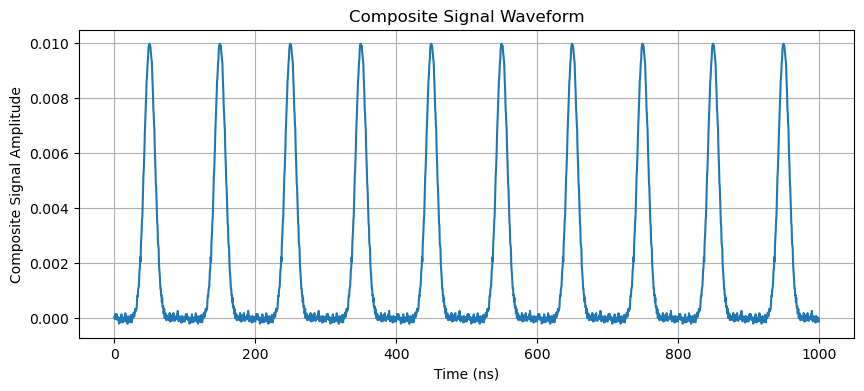

c:\Users\21034\anaconda3\envs\qutip-env\Lib\site-packages\qutip\core\coefficient.py:192: RuntimeWarning: invalid value encountered in divide
  return coefficient_builders[type_](base, **kwargs)


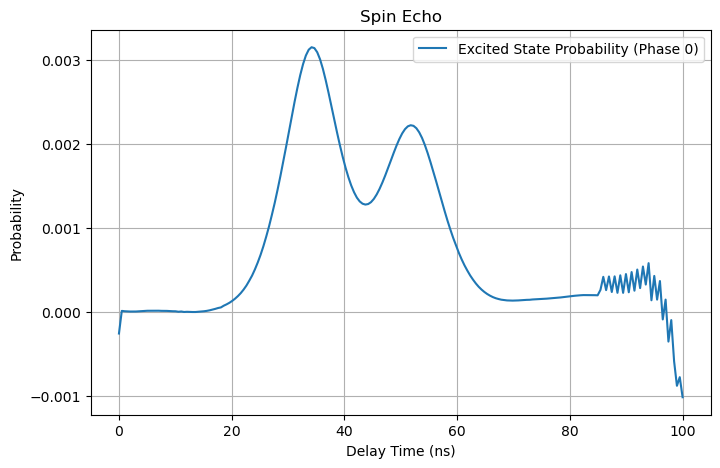

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)
Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
# 总仿真时长

protocal = Protocal(2)

protocal.initialize(qubit,state = 0)

Phi, tau_list, p_e_list, k, t_int = protocal.evolve(qubit)
analysis = Analysis()
B = analysis.get_signal_from_diff_echo(qubit, p_e_list, t_int, k)

plt.figure(figsize=(8, 5))
#plt.plot(tau_list, p_e_list, label='Excited State Probability')
plt.plot(tau_list, B, label='Excited State Probability (Phase 0)')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Spin Echo')

plt.legend()
plt.grid()
plt.show()


## test4: 密度矩阵模拟求核函数
- stim脉冲的幅值不能太大（导致相位超过$2\pi$），也不能太小（小于脉冲信号幅值）
- 可以增加采样率以减少毛刺
- 由于stim脉冲并未理想delta函数，需要对核函数进行标准化（除以高斯函数面积），标准化后的核函数幅值不一定为1，且标准化后的核函数才可以用于准确还原磁场信号

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()
# 使用列表函数代替lambda函数，用时为原来的1/3
control_pulse.get_kernel(qubit)
t_samples, kernel = control_pulse.t_samples, control_pulse.kernel
#t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
t_max = t_samples[max_index]
t_roll = t_samples - t_max
control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_roll]
plt.figure(figsize=(8, 5))
plt.plot(t_roll,kernel_id, label='Ideal Kernel')
plt.plot(t_roll, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

## test5: 瞬态磁场传感协议

注意EC和EJ的单位是rad GHz，T1和T2的单位是ns，频率的单位是GHz，时间的单位是ns。

使用列表函数运算时间是原来的2/3

对于存在突变的磁场还原效果不是很好，会出现振幅不一致，信号振荡的情况

工作点的选取对于还原结果也有影响，在最佳工作点处效果较好，形状和振幅都能还原，但是在其他工作点可以还原出形状，但是振幅不对

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象（与test5相同参数）
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
print(f"Qubit frequency at optimal work point: {qubit.frequency:.4f} GHz")
print(f"Work point flux: {qubit.flux:.4f}")

protocal = Protocal(4)
protocal.initialize(qubit, state=0)
# 获取所有返回值，包括原始磁场信号Phi
t_samples, kernel, scan_list, delta_p, p_e, Phi_signal, control_pulse = protocal.evolve(qubit)

analysis = Analysis()
dt = scan_list[1] - scan_list[0]
# 维纳反卷积，lambda=5.0
B_lists, B_recon = analysis.wiener_deconvolution(delta_p, kernel, dt, lambdas=5.0)

# 原始磁场信号
original_signal = Phi_signal.signal
original_time = Phi_signal.t_list

# 创建符合期刊标准的成果图
fig = plt.figure(figsize=(14, 10))
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})




# 子图4: 重建磁场 vs 原始磁场
ax4 = plt.subplot(1, 1, 1)
ax4.plot(original_time, original_signal, 'b--', linewidth=1.5, label='Original signal')
ax4.plot(B_lists, B_recon, 'r-', linewidth=1.5, label='Reconstructed signal')
ax4.set_xlabel('Time (ns)')
ax4.set_ylabel('Magnetic field (arb. units)')
ax4.set_title('(a) ')
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend()

# 添加信息文本框
# info_text = (
#     f'Qubit parameters:\n'
#     f'$f_{{\\mathrm{{qubit}}}}$ = {qubit.frequency:.4f} GHz\n'
#     f'Work point flux = {qubit.flux:.4f}\n'
#     f'$T_1$ = {qubit.T1:.0f} ns\n'
#     f'$T_2$ = {qubit.T2:.0f} ns\n'
#     f'Deconvolution $\\lambda$ = {5.0}\n'
#     f'Scan points = {len(scan_list)}\n'
#     f'Signal type: Sinusoidal'
#     f'reconstruction method: Wiener deconvolution'
# )
plt.figtext(0.02, 0.02, info_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Transient Magnetic Field Sensing Protocol Results', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.96])  # 为底部文本框留出空间

# 确保输出目录存在
output_dir = 'result/diferent signal'
os.makedirs(output_dir, exist_ok=True)

# 保存图形
output_path = os.path.join(output_dir, 'transient_field_sensing_results(sinusoidal, wiener).png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Results saved to: {output_path}')

# 显示图形
plt.show()

# 可选：保存数据供后续分析
data_path = os.path.join(output_dir, 'reconstruction_data(sinusoidal, wiener).npz')
np.savez(data_path,
         original_time=original_time,
         original_signal=original_signal,
         scan_list=scan_list,
         delta_p=delta_p,
         t_samples=t_samples,
         kernel=kernel,
         B_lists=B_lists,
         B_recon=B_recon)
print(f'Data saved to: {data_path}')

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
print(f"qubit frequency: {qubit.frequency}")
protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _= protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()



In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _= protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


# 非线性响应优化：考虑hammerstein-wiener滤波

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, _, _, _ = protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.hammerstein_wiener_deconvolution(qubit, results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')

plt.figure(figsize=(8, 5))
plt.plot(t_samples, kernel, label='Ideal Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Ideal Control Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


# 非线性响应优化：全密度矩阵模拟
问题
- 使用BSpline基时，伴随法求的雅可比矩阵与有限差分法求的雅可比矩阵不一致
- B_guess本来就是从原磁场反卷积得到，res应该较小，实际为0.06左右。
- 使用fourier基时，在第二次迭代之后，res保持在0.041902，但是res本应该在0处收敛。检查优化算法的实现，极小点应该在res=0处
- 还原的磁场随res减小开始振荡，比res较大时更偏离设定磁场h
- 前向传播和伴随法求雅可比矩阵的时间为5秒左右，可优化
- 思考这个方法能否在实际中使用：能否完美适应出实验环境，能否还原出磁场信号，能否在合理时间内完成优化。

性能
- 在两轮循环之后可以基本还原原磁场的大致形状和幅值，但是对于细节部分不能很好还原，并且res值最多可以优化到0.02，数量级上较高于tol，因此还原出的波形会有一些瑕疵，且如果原磁场比较复杂，或者有突变，则还原结果可能会振荡

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

data = joblib.load('temp_data.joblib')
qubit = data['qubit']
control_pulse = data['control_pulse']
p_meas = data['p_meas']
B_lists = data['B_lists']
B = data['B']
Phi = data['Phi']

analysis = Analysis()
plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.show()

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis, forward_simulation

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)


# Phi = Signal(type = 4, t_list = np.linspace(0, 200, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100)
# Phi.plot()
# result_test = forward_simulation(qubit, Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()

result_test = forward_simulation(qubit, control_pulse, Phi, scan_list, )
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


# test6: cryoscope协议实现

State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70689447+0.01767615j]
 [-0.70504683-0.05382129j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70694304+0.01553617j]
 [-0.70551504-0.04731484j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70699037+0.0134788j ]
 [-0.70590187-0.04105464j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70701637+0.0115074j ]
 [-0.70623403-0.03505603j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70704911+0.00962205j]
 [-0.70649101-0.02931579j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70706701+0.00781745j]
 [-0.70670198-0.02382094j]]
State at t=10.00 ns: Quantum object: dims=[[2]

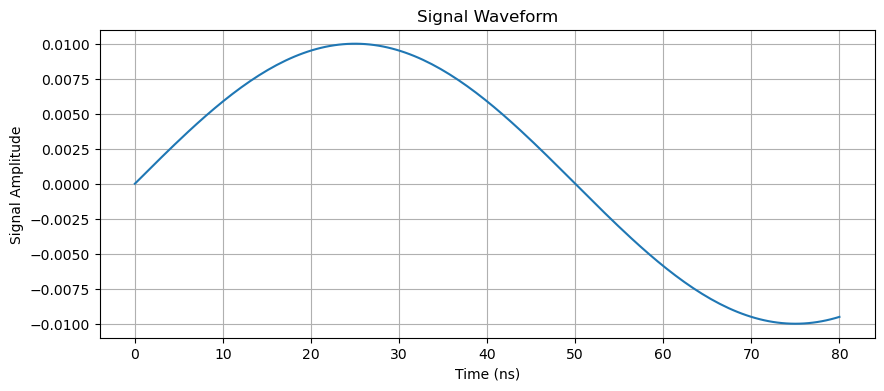

State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70668128-0.04649238j]
 [-0.69029334+0.14810511j]]
State at t=10.00 ns: Quantum object: dims=[[2]

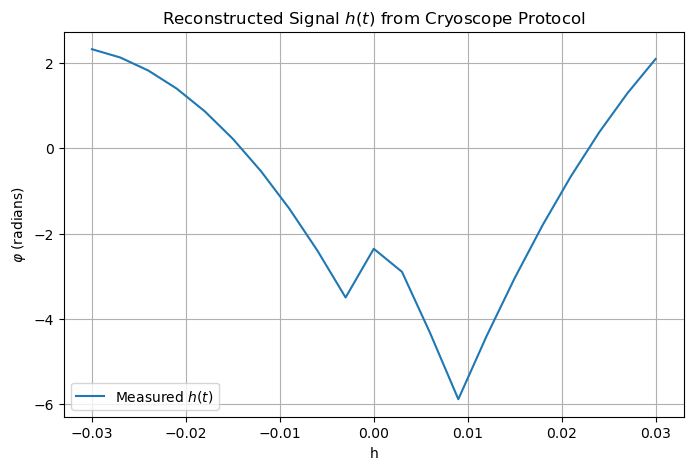

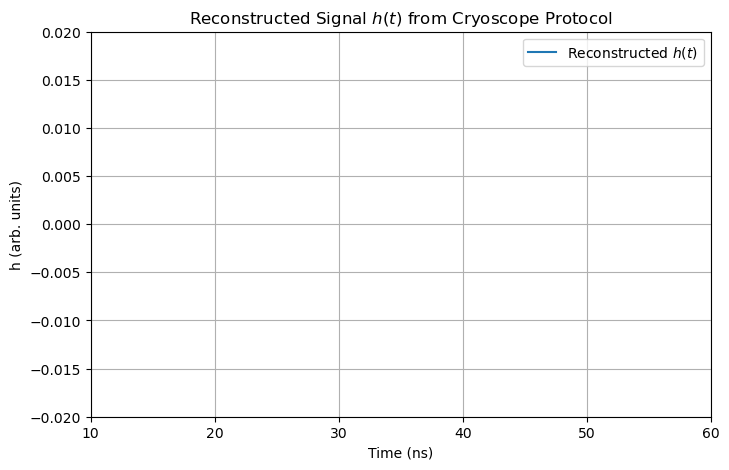

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal, Calibration
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)

Phi0 = qubit.optimal_work_point()
qubit.change_flux(0.95)




protocal = Protocal(5)
protocal.initialize(qubit,state = 0)

# 标定步
calibration = Calibration(qubit, type = 3)
h_list, phi_list, tau = calibration.calibrate()

# 测量步
trunc_list, varphi_meas, _, _ = protocal.evolve(qubit)
dt  = trunc_list[1] - trunc_list[0]
# 分析步
analysis = Analysis()
phi_of_h, h_of_phi = analysis.get_h_from_phi(h_list, phi_list)
trunc_list, h_meas = analysis.get_signal_from_cryoscope(qubit, trunc_list, varphi_meas, h_of_phi, tau, dt)
index = np.searchsorted(h_list, 0)
#phi_list[index] += np.pi
plt.figure(figsize=(8, 5))
plt.plot(h_list, phi_list, label='Measured $h(t)$')
plt.xlabel('h') 
plt.ylabel('$\\varphi$ (radians)')
plt.title('Reconstructed Signal $h(t)$ from Cryoscope Protocol')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(trunc_list, h_meas, label='Reconstructed $h(t)$')
plt.xlim(10, 60)  # 设置x轴范围为0到trunc_list的最后一个值
plt.ylim(-0.02, 0.02)  # 设置y轴范围为0到h_meas的最大值的1.2倍
plt.xlabel('Time (ns)')
plt.ylabel('h (arb. units)')
plt.title('Reconstructed Signal $h(t)$ from Cryoscope Protocol')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit0 = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)
# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.1,
    state = 0,
    n_levels = 2
)
psi_e = basis(qubit.n_levels, 1)
H_0 = qubit.get_hamiltonian_rwa(qubit0.frequency)
t_rabi = np.linspace(0, 5, 100)
composite_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit0.frequency)
H_t = lambda t: H_0 + composite_pulse.get_hamiltonian(t)
result = mesolve(H_t, qubit.state, composite_pulse.t_list, [], e_ops=[psi_e * psi_e.dag()])
p_e = result.expect[0]

print(f"Final excited state probability: {p_e[-1]}")

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()

t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
kernel_roll = np.roll(kernel, -max_index)
t_max = t_samples[max_index]
t_shift = t_samples - t_max
t_roll = np.roll(t_shift, -max_index)

control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_shift]

t_Phi = np.linspace(0, 160, 100)
Phi = Signal(type = 2, t_list = t_Phi)
Phi_list = [Phi.value_at(t) for t in t_Phi]
dt = t_samples[1] - t_samples[0]

delta_p = dt * np.convolve(kernel, Phi_list, mode='full')  # 模拟等效时间采样测量结果，长度为A+B-1 

B = Analysis.wiener_deconvolution(delta_p, kernel, dt, lambdas = 0.0)

print(f'B: {B}')
#delta_p_new = np.convolve(kernel, B, mode='full')  # 用重建的B重新卷积得到测量结果 


plt.figure(figsize=(8, 5))
#plt.plot(t_Phi, Phi_list, label='Phi Signal')
plt.plot(t_Phi, B, label='Reconstructed B Field')
plt.xlabel('Time (ns)')
plt.ylabel('B Field (arb. units)')
plt.title('Reconstructed B Field from Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_samples,kernel_id, label='Ideal Kernel')
plt.plot(t_samples, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

# TODO
- 讨论这些idea的可行性，优先级，以及实现细节
- 完善瞬态磁场协议，增加灵敏度
    - 幅度问题：kernel，反卷积，信号项的系数（响应函数） [参考内容](https://arena.ai/c/019cf09a-0e16-784f-a01f-e8143027d668)
        - 解决：调整stim_pulse 幅度，lambda，使用非线性响应
    - 二阶响应：get_kernel函数和wiener_deconvolution函数中都默认了线性响应，扩展支持二阶响应[参考1](https://arena.ai/c/019d05bf-7b8a-7b86-bed0-a2ecc7924267)[参考2](idea/nonlinear_response_extension.md)
        - 该方法不支持存在负值的磁场。对于有突变函数，该方法可以修正磁场的幅值，
    - 利用优化算法还原磁场信号，如Levenbeig-Marquardt算法
    - 负磁场问题：当前只能测量单一方向的磁场，无法测量负磁场，考虑增加测量负磁场的协议，如添加检测磁场方向的参数。
- 增加更多协议，如spin echo, dynamical decoupling，PEA等 
    - PEA[参考内容](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)[参考2](https://arena.ai/c/019d3830-65e0-700e-960f-376e49b26cd4)
    - 基于微分的传感协议[参考1](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)[参考2](https://arena.ai/c/019d058c-0104-75ba-b70b-b9dac257dfcf)[参考3](https://arena.ai/c/019d058b-7ccd-7b38-98f7-32e97af73ae9)[参考4](idea/differential_sensing_scheme.md)[参考5](https://arena.ai/c/019d3830-65e0-700e-960f-376e49b26cd4)
- 增加实际情况的模拟，如噪声、非理想脉冲等
- 优化程序结构，优化各个模块的接口设计，以及模块内部的实现细节，使得代码更清晰易懂，易于维护和扩展
    - 如，全局统一时间间隔，将数值列表转换为numpy数组，统一使用numpy数组进行计算等
    - 统一全局时间轴，避免在不同模块中使用不同的时间列表，导致混乱和错误
- 优化程序效率，如使用GPU加速，优化算法，使用joblib进行并行计算，以及优化mesolve的传入量，避免用lambda等[参考](https://arena.ai/c/019d38a2-eda2-7dc0-bfb1-200f52db8e0f)
    - 传入函数
        - 解决：
            - 对重复调用的函数和列表进行预计算
            - 避免使用Python对象，如Python回调函数，Qobj等，尽量使用qutip的列表函数和numpy数组等
    - GPU加速，算法优化，joblib
- 完善demo，增加交互性
- 撰写README.md
<!-- - 实验室实习 [参考内容](https://arena.ai/c/019cf0a9-ca57-7e1e-bdd9-b0d7ea303a19)
-->

# TODO in detail
- 完善瞬态磁场传感，生成报告图表
    - 全密度矩阵模拟
    - 正负磁场
- 加噪声
- 实现ramsey，spin echo，CPMG协议，并比较其对于噪声和能级泄露的优势
- 实现差分回波协议[参考](https://arena.ai/c/019d7121-a5db-797d-bb40-6b9a0c370a39)
- 综合比较以上所有协议在Transmon qubit上的性能，包括时间分辨率，灵敏度等
- spinecho和现有的滑动测量结合，发挥spinecho可以得到磁场导数的优势（微分传感，选做）
- 并行优化，代码结构优化，demo实现
- 结题报告

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)


t_rabi = np.linspace(0, 40, 100)
Phi = Signal(type = 2, t_list = t_rabi, amplitude = 0.1)
noise = qubit.generate_1f_noise(t_rabi, amplitude=0.001, f_min=1e-3, f_max=1e3)
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, noise+Phi.signal, label='1/f Noise')
#plt.ylim(0.1-0.01, 0.1+0.01)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude (arb. units)')
plt.title('Generated 1/f Noise')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
t_rabi =  np.linspace(0, 200, 400)
Phi = Signal(type = 4, t_list = np.linspace(0, 200, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100)
Phi.plot()
B = (1 / np.pi) * np.arccos((0.000001 + qubit.frequency + qubit.EC) ** 2 / (8 * qubit.EC * qubit.EJ))  # 根据Transmon的频率-磁场关系，得到磁场响应
print(f'B: {B} ')
'''
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, B, label='B Field from Phi')
plt.xlabel('Time (ns)') 
plt.ylabel('B Field (arb. units)')
plt.title('B Field from Phi Signal')
plt.grid()
plt.show()
'''

In [ ]:
import qutip as qt
print(qt.__version__)  # 5.2.0

# 简单测试
H = qt.sigmaz()
psi0 = qt.basis(2, 0)
tlist = [0, 0.1]

# 不设 options
result1 = qt.mesolve(H, psi0, tlist, [], [])
print(f"Without options: {result1.states[0].shape}")  # 应该是 (2,2)

# 设 options
options = qt.Options(store_states=True)
result2 = qt.mesolve(H, psi0, tlist, [], [], options=options)
print(f"With options: {result2.states[0].shape}")  # 应该是 (2,2)

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)


Phi0 = qubit.optimal_work_point()
qubit.change_flux(Phi0)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results, p_meas, Phi, control_pulse = protocal.evolve(qubit)
analysis = Analysis()
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
joblib.dump({
    'qubit':qubit,
    'control_pulse':control_pulse,
    'p_meas':p_meas,
    'B_lists':B_lists,
    'B':B,
    'Phi':Phi
}, 'temp_data.joblib')

B_opt, history = analysis.numerical_inverse(qubit, control_pulse, p_meas, B_lists, B)

plt.figure(figsize=(8, 5))
plt.plot(Phi.t_list, B, label='magnetic field from wiener deconvolution')
plt.plot(Phi.t_list, B_opt, label='magnetic field from numerical inverse')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import joblib

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

Phi = Signal(type = 7, t_list = np.linspace(0, 1100, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100, noise_level = 0.01)
Phi.plot()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义生成信号的函数 ---

def generate_replicated_signal(num_points=150, noise_level=1.8, seed=42):
    """
    生成复现的信号数据。

    参数:
    num_points (int): 数据点的数量。
    noise_level (float): 添加的高斯噪声的标准差 (sigma)。
    seed (int): 随机数种子，用于保证结果可复现。

    返回:
    tuple: (tlist, signallist)，分别为时间列表和信号列表。
    """
    
    # 定义高斯调制余弦波包的辅助函数
    def wave_packet(t, A, t0, w, f, phi):
        """
        t: 时间数组
        A: 振幅
        t0: 波包中心时间
        w: 高斯包络的宽度 (标准差)
        f: 频率
        phi: 相位
        """
        return A * np.exp(-(t - t0)**2 / (2 * w**2)) * np.cos(2 * np.pi * f * (t - t0) + phi)

    # --- 2. 创建时间轴 (tlist) ---
    tlist = np.linspace(0, 1100, num_points)

    # --- 3. 构建理想信号 (黑色虚线) ---
    # 通过叠加5个不同的波包来模拟复杂信号
    # 参数 (A, t0, w, f, phi) 是根据原始图像目测估算的

    # 第一个大波包 (t≈400)
    p1 = wave_packet(tlist, A=30, t0=420, w=60, f=0.01, phi=0.4 * np.pi)
    
    # 第二个大波包 (t≈700)
    p2 = wave_packet(tlist, A=28, t0=700, w=70, f=0.0125, phi=0.5 * np.pi)

    # 中间的次级波包 (t≈500)
    p3 = wave_packet(tlist, A=14, t0=515, w=35, f=0.011, phi=0.25 * np.pi)

    # 右侧的次级波包 (t≈820)
    p4 = wave_packet(tlist, A=12, t0=825, w=45, f=0.012, phi=0)

    # 初始的小波包 (t≈250)
    p5 = wave_packet(tlist, A=4.0, t0=250, w=70, f=0.0083, phi=1.5 * np.pi)

    # 将所有波包相加得到最终的理想信号
    signal_ideal = p1 + p2 + p3 + p4 + p5

    # --- 4. 添加高斯噪声 ---
    # 设置随机数种子以确保每次运行结果相同
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
    
    # 最终的信号列表 (蓝色数据点)
    signallist = signal_ideal + noise
    
    return tlist, signallist, signal_ideal

# --- 5. 生成数据并绘制图像以供验证 ---
tlist, signallist, signal_ideal = generate_replicated_signal()

# 绘制复现的信号图
plt.figure(figsize=(12, 6))
plt.scatter(tlist, signallist, s=30, alpha=0.8, label='Replicated Data (signallist)')
plt.plot(tlist, signal_ideal, 'k--', linewidth=2, label='Ideal Signal Model')
plt.title("Replicated Signal from Image", fontsize=16)
plt.xlabel("t", fontsize=12)
plt.ylabel("B(t) (μT)", fontsize=12)
plt.xlim(0, 1150)
plt.ylim(-30, 35)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# --- 6. 打印生成的 tlist 和 signallist ---
# 为了方便复制，将列表格式化输出
print("--- Generated tlist ---")
print("tlist = [", end="")
print(*[f"{t:.2f}" for t in tlist], sep=", ", end="]\n\n")

print("--- Generated signallist ---")
print("signallist = [", end="")
print(*[f"{val:.4f}" for val in signallist], sep=", ", end="]\n")

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, create_diff_echo_pulse, create_cpmg_pulse
from src.protocal import Protocal
from src.analysis import Analysis

t_rabi = np.linspace(0, 200, 400)
tau_list = np.linspace(0, 250, 500)
for tau in tau_list:
    pulse = create_diff_echo_pulse(t_rabi, tau, t_int = 100, t_rep = 200, k = 10, omega_d=1)
#pulse = create_cpmg_pulse(t_rabi, tau=20, n=100, omega_d=1)